# Practice 01 — Linear Regression

**Goal:** solve one problem several ways and check that they reach the same answer.

$$\hat{\mathbf{y}} = \mathbf{Xw}, \qquad
J = \tfrac{1}{2}\lVert\hat{\mathbf{y}} - \mathbf{y}\rVert_2^2, \qquad \mathbf{E} = \mathbf{y} -
\hat{\mathbf{y}}, \qquad \frac{\partial J}{\partial \mathbf{w}} = -\mathbf{X}^T\mathbf{E}, \qquad \mathbf{w}
\leftarrow \mathbf{w} - \rho\,\frac{\partial J}{\partial \mathbf{w}}$$

$$\mathbf{X} = \begin{bmatrix} 1 & x_1 \\ \vdots & \vdots \\ 1 & x_N \end{bmatrix}\;(N, 2), \qquad
\mathbf{w} = \begin{bmatrix} w_0 \\ w_1 \end{bmatrix}\;(2, 1)$$

- $\tfrac{1}{2}$ in $J$ → cancels the 2 from differentiating, so formula and autograd match exactly

| Step | Method | Solved by |
|:---|:---|:---|
| 2 | Least squares | closed form |
| 3 | GD — NumPy | hand-derived gradient |
| 6 | GD — autograd | `loss.backward()` |
| 7 | GD — PyTorch | `torch.nn` + `torch.optim` |
| 8 | scikit-learn | closed form |

---
## Step 0. Imports

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['axes.unicode_minus'] = False

---
## Step 1. Generate Data

$$y = 0.1 + 0.3\,x + \mathcal{N}(0,\, 0.1), \qquad N = 100$$

- True values to recover: $w_0 = 0.1$, $w_1 = 0.3$

x: (100, 1)
y: (100, 1)


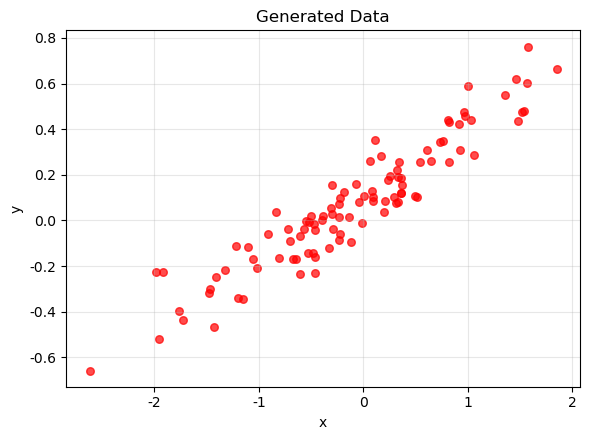

In [2]:
N  = 100      # number of samples
w0 = 0.1      # true intercept
w1 = 0.3      # true slope

x = np.random.normal(0.0, 1, N).reshape(-1, 1)
y = w0 + w1 * x + np.random.normal(0.0, 0.1, N).reshape(-1, 1)   # add noise

print(f'x: {x.shape}')
print(f'y: {y.shape}')

plt.figure(figsize=(6, 4.5))
plt.scatter(x, y, c='r', s=30, alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 2. Least Square Method

$$\mathbf{w}^* = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

- $\mathbf{X}$ = `[1, x]` → the intercept is part of $\mathbf{w}$
- Closed form → one line, no iteration

X: (100, 2)
w: (2, 1)
w0, w1 : 0.1007, 0.2857   (true: 0.1, 0.3)


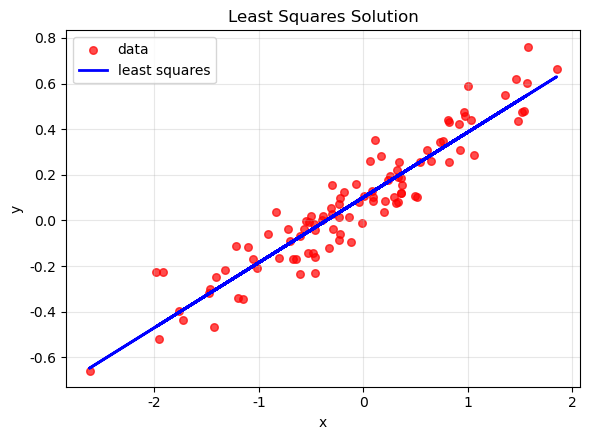

In [3]:
X = np.hstack([x**0, x])   # augmented matrix [1, x]

w_least_squares = np.linalg.inv(X.T @ X) @ X.T @ y   # normal equation
y_hat_least_squares = X @ w_least_squares

print(f'X: {X.shape}')
print(f'w: {w_least_squares.shape}')
print(f'w0, w1 : {w_least_squares[0, 0]:.4f}, {w_least_squares[1, 0]:.4f}   (true: {w0}, {w1})')

plt.figure(figsize=(6, 4.5))
plt.scatter(x, y, c='r', s=30, alpha=0.7, label='data')
plt.plot(x, y_hat_least_squares, 'b-', linewidth=2, label='least squares')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares Solution')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 3. Gradient Descent — NumPy

$$\hat{\mathbf{y}} = \mathbf{Xw} \;\rightarrow\;
\mathbf{E} = \mathbf{y} - \hat{\mathbf{y}} \;\rightarrow\; \frac{\partial J}{\partial \mathbf{w}} =
-\mathbf{X}^T\mathbf{E} \;\rightarrow\; \mathbf{w} \leftarrow \mathbf{w} - \rho\,\frac{\partial J}{\partial
\mathbf{w}}$$

- Each term above → one line in the loop
- `rho`, `n_iter` → reused by every gradient descent method below
- `w_init` → shared with autograd (Step 6) only

In [4]:
w_init = np.random.randn(2, 1)   # initial weights
rho    = 0.00002
n_iter = 3000

w_numpy = w_init.copy()
loss_history_numpy = []
w_history = []

for i in range(n_iter):
    y_hat = X @ w_numpy               # prediction
    E     = y - y_hat                 # residual
    dJ    = -X.T @ E                  # gradient
    w_numpy = w_numpy - rho * dJ      # update

    loss_history_numpy.append(float((E ** 2).sum() / 2))   # J = (1/2)||E||^2
    w_history.append(w_numpy[:, 0])

y_hat_numpy = X @ w_numpy

print(f'initial loss : {loss_history_numpy[0]:.4f}')
print(f'final loss   : {loss_history_numpy[-1]:.4f}')
print(f'w0, w1       : {w_numpy[0, 0]:.4f}, {w_numpy[1, 0]:.4f}   (true: {w0}, {w1})')

initial loss : 6.1418
final loss   : 0.4423
w0, w1       : 0.1024, 0.2886   (true: 0.1, 0.3)


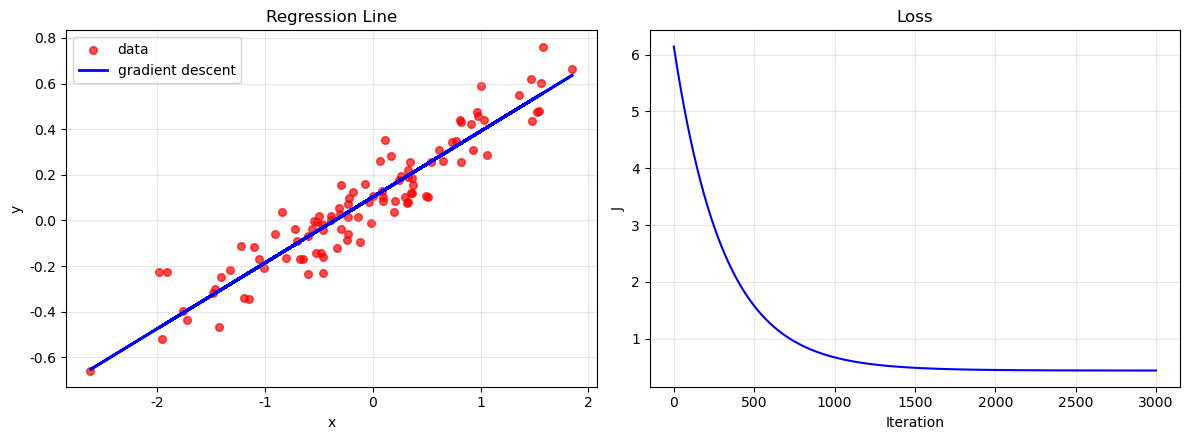

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(x, y, c='r', s=30, alpha=0.7, label='data')
axes[0].plot(x, y_hat_numpy, 'b-', linewidth=2, label='gradient descent')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Regression Line')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(loss_history_numpy, 'b-', linewidth=1.5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('J')
axes[1].set_title('Loss')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

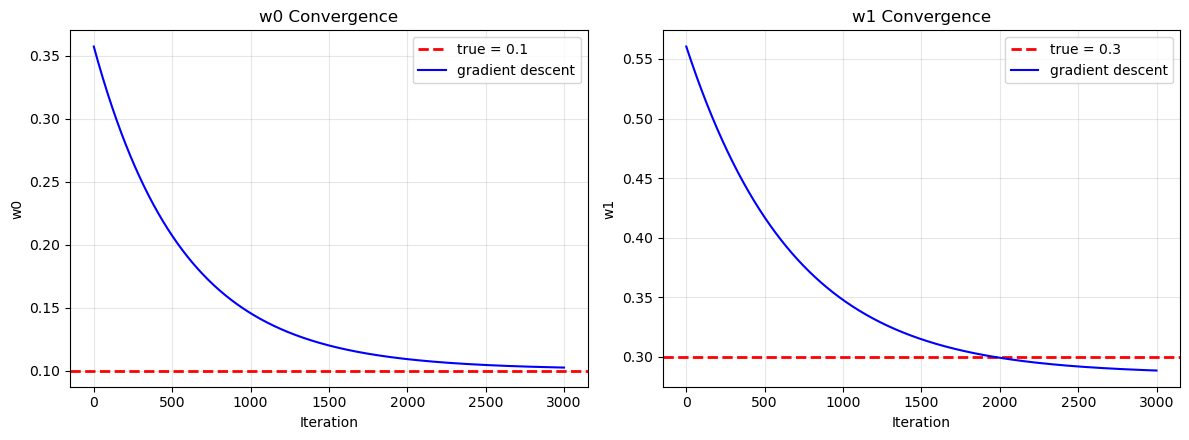

In [6]:
w_history = np.array(w_history)   # (n_iter, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].axhline(w0, color='r', linestyle='--', linewidth=2, label=f'true = {w0}')
axes[0].plot(w_history[:, 0], 'b-', linewidth=1.5, label='gradient descent')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('w0')
axes[0].set_title('w0 Convergence')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(w1, color='r', linestyle='--', linewidth=2, label=f'true = {w1}')
axes[1].plot(w_history[:, 1], 'b-', linewidth=1.5, label='gradient descent')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('w1')
axes[1].set_title('w1 Convergence')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 4. Autograd

PyTorch differentiates the forward computation for you.

| API | Role |
|:---|:---|
| `torch.tensor(v, requires_grad=True)` | track gradients |
| `y.backward()` | compute the derivatives |
| `w_tensor.grad` | read them |

### Example 1: $y = w^2 + 2w + 1$

$$\frac{dy}{dw} = 2w + 2$$

**Expected** at $w = 2$: $y = 9$, $\dfrac{dy}{dw} = 6$

In [7]:
w_value = 2.0   # try other values

w_tensor  = torch.tensor(w_value, requires_grad=True)
y_example = w_tensor**2 + 2*w_tensor + 1

y_example.backward()

print(f'w     : {w_tensor.item()}')
print(f'y     : {y_example.item()}')
print(f'dy/dw : {w_tensor.grad.item()}')   # 2w + 2 = 6

w     : 2.0
y     : 9.0
dy/dw : 6.0


### Example 2: $\hat{y} = xw + 1$

$$\frac{d\hat{y}}{dw} = x$$

**Expected** at $x = 3$, $w = 2$: $\hat{y} = 7$, $\dfrac{d\hat{y}}{dw} = 3$

In [8]:
x_value = 3.0
w_value = 2.0

w_tensor      = torch.tensor(w_value, requires_grad=True)
y_hat_example = x_value * w_tensor + 1

y_hat_example.backward()

print(f'w     : {w_tensor.item()}')
print(f'y_hat : {y_hat_example.item()}')
print(f'dy/dw : {w_tensor.grad.item()}')   # x = 3

w     : 2.0
y_hat : 7.0
dy/dw : 3.0


### Example 3: $\hat{y} = xw + 1$, $\; f = \hat{y}^2$ — chain rule

$$\frac{df}{dw} = \frac{d\hat{y}}{dw}\cdot\frac{df}{d\hat{y}} = 2x\hat{y}$$

**Expected** at $x = 3$, $w = 2$: $\hat{y} = 7$, $f = 49$, $df/dw = 42$ — two stages, one `backward()`

In [9]:
x_value = 3.0
w_value = 2.0

w_tensor      = torch.tensor(w_value, requires_grad=True)
y_hat_example = x_value * w_tensor + 1
f_example     = y_hat_example**2

f_example.backward()

print(f'w     : {w_tensor.item()}')
print(f'y_hat : {y_hat_example.item()}')
print(f'f     : {f_example.item()}')
print(f'df/dw : {w_tensor.grad.item()}')   # 2 * x * y_hat = 2 * 3 * 7 = 42

w     : 2.0
y_hat : 7.0
f     : 49.0
df/dw : 42.0


---
## Step 5. Hand-Derived Gradient vs. Autograd

- Same $\mathbf{w}$, two gradients, printed side by side
- Match → the Step 3 derivation is right

In [10]:
w_check = np.array([[1.0], [1.0]])   # any w works

# from the formula
y_hat = X @ w_check
E     = y - y_hat
dJ_formula = -X.T @ E

# from autograd
X_tensor = torch.tensor(X, dtype=torch.float64)   # float64, to match NumPy exactly
y_tensor = torch.tensor(y, dtype=torch.float64)
w_check_tensor = torch.tensor(w_check, dtype=torch.float64, requires_grad=True)

loss = ((X_tensor @ w_check_tensor - y_tensor) ** 2).sum() / 2
loss.backward()

print(f'formula  : {dJ_formula.flatten()}')
print(f'autograd : {w_check_tensor.grad.numpy().flatten()}')

formula  : [82.50769791 49.75814305]
autograd : [82.50769791 49.75814305]


---
## Step 6. Gradient Descent — autograd, manual update

| Step 3 | Here |
|:---|:---|
| `dJ = -X.T @ E` | `loss.backward()` |
| `w = w - rho * dJ` | `w -= rho * w.grad` |

- `.grad` **accumulates** → clear it every iteration with `grad.zero_()`
- The update must not be differentiated → `with torch.no_grad()`

In [11]:
w_autograd = torch.tensor(w_init, dtype=torch.float64, requires_grad=True)
loss_history_autograd = []

for i in range(n_iter):
    y_hat = X_tensor @ w_autograd                  # prediction
    loss  = ((y_hat - y_tensor) ** 2).sum() / 2    # J = (1/2)||E||^2

    loss.backward()                                # autograd computes the gradient
    with torch.no_grad():
        w_autograd -= rho * w_autograd.grad        # update
    w_autograd.grad.zero_()                        # clear the accumulated gradient

    loss_history_autograd.append(loss.item())

print(f'initial loss : {loss_history_autograd[0]:.4f}')
print(f'final loss   : {loss_history_autograd[-1]:.4f}')
print(f'w0, w1       : {w_autograd[0, 0].item():.4f}, {w_autograd[1, 0].item():.4f}   (true: {w0}, {w1})')

initial loss : 6.1418
final loss   : 0.4423
w0, w1       : 0.1024, 0.2886   (true: 0.1, 0.3)


---
## Step 7. Gradient Descent — `nn.Module`, `nn.MSELoss`, `torch.optim`

| Step 6 | Here |
|:---|:---|
| `X_tensor @ w` | `model(x_tensor)` |
| `((y_hat - y_tensor) ** 2).sum() / 2` | `loss_fn(y_hat, y_tensor) / 2` |
| `w -= rho * w.grad`, `w.grad.zero_()` | `optimizer.step()`, `optimizer.zero_grad()` |

### Model

- `__init__` → declare the layers, `forward` → compute $\hat{\mathbf{y}}$
- `nn.Linear` starts from **random** weight and bias, not `w_init`

In [12]:
class LinearRegressor(torch.nn.Module):
    def __init__(self, in_features):
        super().__init__()                              # required, or no parameter is tracked
        self.linear = torch.nn.Linear(in_features, 1)   # weight = w1, bias = w0

    def forward(self, x):
        y_hat = self.linear(x)                          # called as model(x)
        return y_hat


torch.manual_seed(42)
model = LinearRegressor(in_features=1).double()   # float64, like the other tensors
print(model)
print(f'initial w0, w1 : {model.linear.bias.item():.4f}, {model.linear.weight.item():.4f}')

LinearRegressor(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
initial w0, w1 : 0.8300, 0.7645


### Input, Optimizer and Loss

| Name | Key point |
|:---|:---|
| `x_tensor` | **raw** `x` $(N, 1)$ — `nn.Linear` already has the bias |
| `optimizer` | SGD with the same `rho` |
| `loss_fn` | `reduction='sum'` → $\lVert\mathbf{E}\rVert_2^2$, halved to match $J$ (default `'mean'` divides by $N$) |

In [13]:
x_tensor = torch.tensor(x, dtype=torch.float64)   # raw x, no column of ones

optimizer = torch.optim.SGD(model.parameters(), lr=rho)
loss_fn   = torch.nn.MSELoss(reduction='sum')      # ||E||^2, summed over samples

print(f'X_tensor: {tuple(X_tensor.shape)}   (augmented, Steps 5-6)')
print(f'x_tensor: {tuple(x_tensor.shape)}   (raw, nn.Linear)')

X_tensor: (100, 2)   (augmented, Steps 5-6)
x_tensor: (100, 1)   (raw, nn.Linear)


### Training

- Same loop as Step 6, with the three replacements above

In [14]:
loss_history_pytorch = []

for i in range(n_iter):
    y_hat = model(x_tensor)                   # prediction
    loss  = loss_fn(y_hat, y_tensor) / 2      # J = (1/2)||E||^2

    loss.backward()           # autograd computes the gradients
    optimizer.step()          # the optimizer updates every model parameter
    optimizer.zero_grad()     # clear the accumulated gradients

    loss_history_pytorch.append(loss.item())

bias_pytorch   = model.linear.bias.item()     # w0
weight_pytorch = model.linear.weight.item()   # w1

print(f'initial loss : {loss_history_pytorch[0]:.4f}')
print(f'final loss   : {loss_history_pytorch[-1]:.4f}')
print(f'w0, w1       : {bias_pytorch:.4f}, {weight_pytorch:.4f}   (true: {w0}, {w1})')

initial loss : 32.8922
final loss   : 0.4437
w0, w1       : 0.1044, 0.2916   (true: 0.1, 0.3)


---
## Step 8. Solving with scikit-learn

- `LinearRegression` → least squares internally
- Takes the raw $x$; the intercept is fitted separately
- `intercept_` → $w_0$, `coef_` → $w_1$

In [15]:
regressor = LinearRegression()
regressor.fit(x, y)

w_sklearn = np.array([[regressor.intercept_[0]], [regressor.coef_[0, 0]]])

print(f'w0, w1 : {w_sklearn[0, 0]:.4f}, {w_sklearn[1, 0]:.4f}   (true: {w0}, {w1})')

w0, w1 : 0.1007, 0.2857   (true: 0.1, 0.3)


---
## Step 9. Comparing the Results

| Method | Starting point | Expected result |
|:---|:---|:---|
| Least squares, scikit-learn | none (closed form) | the exact optimum |
| NumPy, autograd | `w_init` | identical to each other |
| PyTorch | random (`nn.Linear`) | close, but not identical |

- 3000 iterations stop slightly short of the optimum → the starting point shows in the last digits

In [16]:
loss_least_squares = float(((y - y_hat_least_squares) ** 2).sum() / 2)   # J at the exact optimum

print(f'True values   : w0 = {w0:.6f}, w1 = {w1:.6f}')
print(f'Least Squares : w0 = {w_least_squares[0, 0]:.6f}, w1 = {w_least_squares[1, 0]:.6f}, J = {loss_least_squares:.6f}')
print(f'scikit-learn  : w0 = {w_sklearn[0, 0]:.6f}, w1 = {w_sklearn[1, 0]:.6f}')
print(f'GD - NumPy    : w0 = {w_numpy[0, 0]:.6f}, w1 = {w_numpy[1, 0]:.6f}, J = {loss_history_numpy[-1]:.6f}')
print(f'GD - autograd : w0 = {w_autograd[0, 0].item():.6f}, w1 = {w_autograd[1, 0].item():.6f}, J = {loss_history_autograd[-1]:.6f}')
print(f'GD - PyTorch  : w0 = {bias_pytorch:.6f}, w1 = {weight_pytorch:.6f}, J = {loss_history_pytorch[-1]:.6f}')

True values   : w0 = 0.100000, w1 = 0.300000
Least Squares : w0 = 0.100743, w1 = 0.285674, J = 0.441816
scikit-learn  : w0 = 0.100743, w1 = 0.285674
GD - NumPy    : w0 = 0.102354, w1 = 0.288608, J = 0.442254
GD - autograd : w0 = 0.102354, w1 = 0.288608, J = 0.442254
GD - PyTorch  : w0 = 0.104446, w1 = 0.291591, J = 0.443728


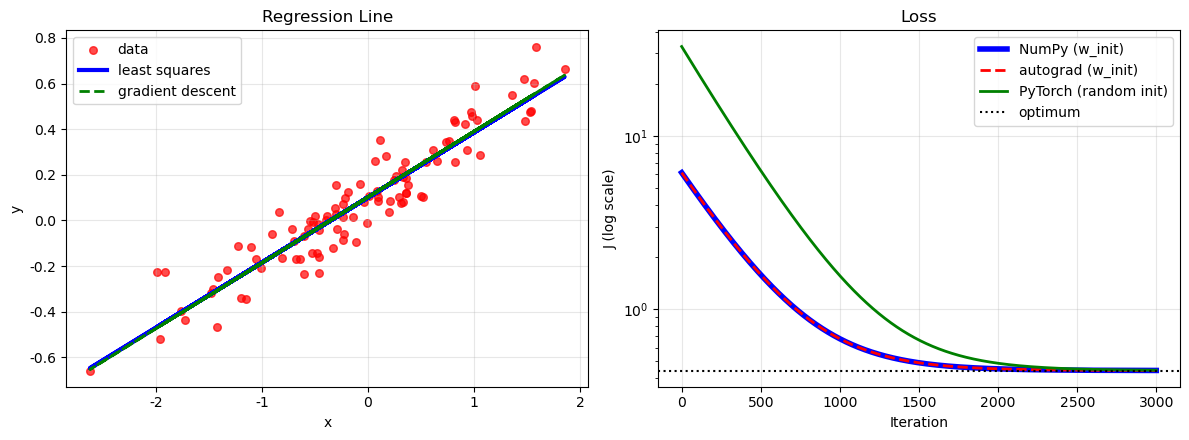

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(x, y, c='r', s=30, alpha=0.7, label='data')
axes[0].plot(x, y_hat_least_squares, 'b-', linewidth=3, label='least squares')
axes[0].plot(x, y_hat_numpy, 'g--', linewidth=2, label='gradient descent')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Regression Line')
axes[0].legend()
axes[0].grid(alpha=0.3)

# NumPy and autograd overlap; PyTorch starts elsewhere and meets them
axes[1].plot(loss_history_numpy, 'b-', linewidth=4, label='NumPy (w_init)')
axes[1].plot(loss_history_autograd, 'r--', linewidth=2, label='autograd (w_init)')
axes[1].plot(loss_history_pytorch, 'g-', linewidth=2, label='PyTorch (random init)')
axes[1].axhline(loss_least_squares, color='k', linestyle=':', linewidth=1.5, label='optimum')
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('J (log scale)')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

| Method | Gradient | Update | Still by hand |
|:---|:---|:---|:---|
| NumPy | `-X.T @ E` | `w - rho * dJ` | loss, model |
| autograd | `loss.backward()` | `w -= rho * w.grad` | loss, model |
| PyTorch | `loss.backward()` | `optimizer.step()` | — |

- More work moves to PyTorch in each row; the arithmetic, and so the answer, stays the same

---
## Exercises

1. `rho = 0.0001`, then `0.001` — what happens?
2. `n_iter = 100` — does gradient descent reach the least squares solution?
3. `w0 = 2.0`, `w1 = -0.5` — solve again.
4. Add a second input $x_2$: $\mathbf{X}$ → $(N, 3)$, $\mathbf{w}$ → $(3, 1)$ — the four loop lines stay the same.

In [18]:
# Write your code here